**6402. Новикова Виктория.**



отчет по бинарной классификации (без нормализации):
              precision    recall  f1-score   support

           0       0.34      0.46      0.39       231
           1       0.64      0.52      0.58       426

    accuracy                           0.50       657
   macro avg       0.49      0.49      0.48       657
weighted avg       0.54      0.50      0.51       657

отчет по бинарной классификации (после нормализации):
              precision    recall  f1-score   support

           0       0.57      0.75      0.65       231
           1       0.84      0.70      0.76       426

    accuracy                           0.72       657
   macro avg       0.70      0.72      0.70       657
weighted avg       0.74      0.72      0.72       657



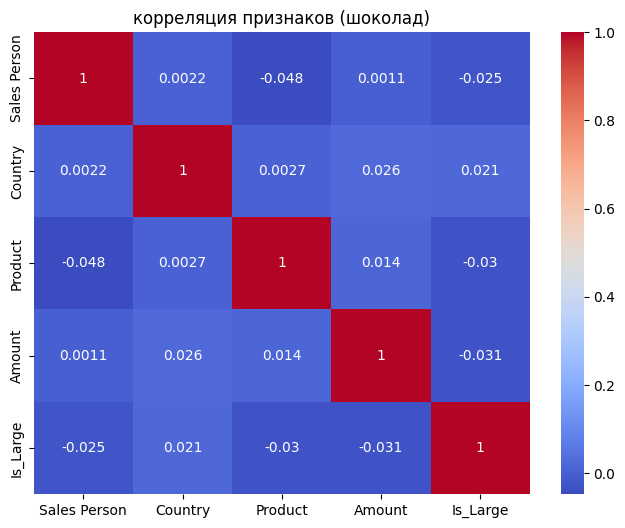

выбранные важные признаки: ['Amount', 'Product', 'Sales Person']
отчет после фильтрации признаков:
              precision    recall  f1-score   support

           0       0.55      0.77      0.64       231
           1       0.84      0.65      0.74       426

    accuracy                           0.69       657
   macro avg       0.69      0.71      0.69       657
weighted avg       0.74      0.69      0.70       657



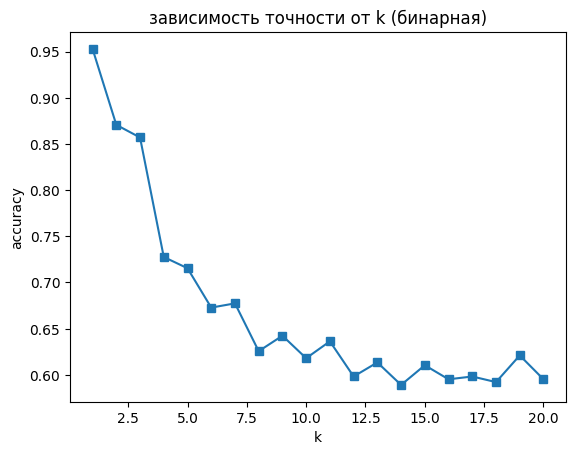

лучшее k по кросс-валидации: 1
отчет по многоклассовой классификации (страны):
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       123
           1       0.94      0.92      0.93        92
           2       0.87      0.97      0.92       104
           3       0.97      0.95      0.96       101
           4       0.94      0.91      0.92       113
           5       0.92      0.91      0.91       124

    accuracy                           0.92       657
   macro avg       0.92      0.92      0.92       657
weighted avg       0.92      0.92      0.92       657



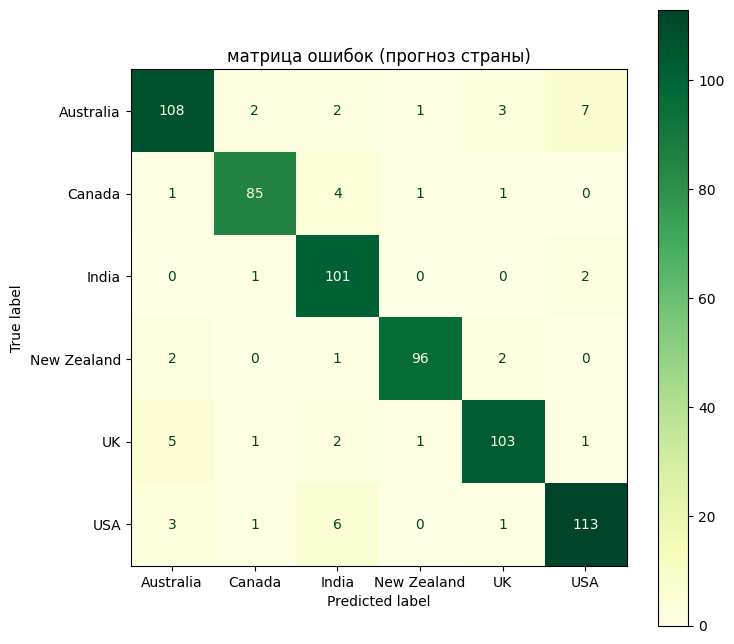

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

# 1. считывание данных
# загружаем твой файл
df = pd.read_csv('/content/drive/MyDrive/Учёба/8 семестр/ТИИ/Chocolate Sales (2).csv')

# очистка данных (удаляем знаки $ и запятые, чтобы Amount стал числом)
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True).astype(float)

# 2. бинарная классификация

# описание датасета
"""
Датасет содержит данные о продажах шоколада в разных странах.
Цель — предсказать, является ли партия крупной (Is_Large: > 100 коробок).

Таблица признаков:
Признак            Описание                          Единицы измерения
Sales Person       Имя продавца                      Строка (категория)
Country            Страна продажи                    Категория
Product            Тип продукта                      Категория
Date               Дата продажи                      Дата
Amount             Сумма сделки                      Доллары США
Boxes Shipped      Количество коробок                Штуки
Is_Large           Целевой признак (>100 коробок)    0 или 1
"""

# предобработка (подчистка данных)
# создаем целевой признак: 1 если отправлено > 100 коробок, иначе 0
df['Is_Large'] = (df['Boxes Shipped'] > 100).astype(int)

# удаляем дату и саму колонку Boxes Shipped (чтобы модель не знала ответ заранее)
df_bin = df.drop(['Date', 'Boxes Shipped'], axis=1).dropna()

# кодирование категориальных признаков
le = LabelEncoder()
for col in ['Sales Person', 'Country', 'Product']:
    df_bin[col] = le.fit_transform(df_bin[col])

x = df_bin.drop('Is_Large', axis=1)
y = df_bin['Is_Large']

# разбиение выборки
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# устранение дисбаланса классов
ros = RandomOverSampler(random_state=42)
x_train_res, y_train_res = ros.fit_resample(x_train, y_train)

# а) классификация без нормализации
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(x_train_res, y_train_res)
y_pred_raw = knn_raw.predict(x_test)
print("отчет по бинарной классификации (без нормализации):")
print(classification_report(y_test, y_pred_raw))

# б) нормализация данных
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_res)
x_test_scaled = scaler.transform(x_test)

knn_norm = KNeighborsClassifier(n_neighbors=5)
knn_norm.fit(x_train_scaled, y_train_res)
y_pred_norm = knn_norm.predict(x_test_scaled)
print("отчет по бинарной классификации (после нормализации):")
print(classification_report(y_test, y_pred_norm))

# в) фильтрация признаков через корреляцию
plt.figure(figsize=(8, 6))
sns.heatmap(df_bin.corr(), annot=True, cmap='coolwarm')
plt.title('корреляция признаков (шоколад)')
plt.show()

# выбираем топ-3 важных признака
important_features = df_bin.corr().abs()['Is_Large'].sort_values(ascending=False).iloc[1:4].index.tolist()
print(f"выбранные важные признаки: {important_features}")

x_train_filt = pd.DataFrame(x_train_scaled, columns=x.columns)[important_features]
x_test_filt = pd.DataFrame(x_test_scaled, columns=x.columns)[important_features]

knn_filt = KNeighborsClassifier(n_neighbors=5)
knn_filt.fit(x_train_filt, y_train_res)
y_pred_filt = knn_filt.predict(x_test_filt)
print("отчет после фильтрации признаков:")
print(classification_report(y_test, y_pred_filt))

# г) перебор k и график точности
k_range = range(1, 21)
test_accuracies = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train_res)
    test_accuracies.append(model.score(x_test_scaled, y_test))

plt.plot(k_range, test_accuracies, marker='s')
plt.title('зависимость точности от k (бинарная)')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

# 3. многоклассовая классификация

# описание датасета
"""
Датасет содержит данные о продажах шоколада.
Цель — предсказать страну поставки (Country) на основе данных о сделке.

Таблица признаков:
Признак            Описание                          Единицы измерения
Sales Person       Имя продавца                      Категория
Product            Тип продукта                      Категория
Amount             Сумма сделки                      Доллары США
Boxes Shipped      Количество коробок                Штуки
Country            Целевой признак (Страна)          Категория
"""

# предобработка для многоклассовой задачи
df_multi = df.drop(['Date', 'Is_Large'], axis=1).dropna()
target_le = LabelEncoder()
df_multi['Country'] = target_le.fit_transform(df_multi['Country'])

for col in ['Sales Person', 'Product']:
    df_multi[col] = le.fit_transform(df_multi[col])

xm = df_multi.drop('Country', axis=1)
ym = df_multi['Country']

# нормализация и сплит
xm_scaled = scaler.fit_transform(xm)
xm_train, xm_test, ym_train, ym_test = train_test_split(xm_scaled, ym, test_size=0.2, random_state=42)

# поиск k через кросс-валидацию
cv_scores = []
for k in range(1, 15):
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), xm_train, ym_train, cv=3)
    cv_scores.append(scores.mean())

best_k = np.argmax(cv_scores) + 1
print(f"лучшее k по кросс-валидации: {best_k}")

# итоговая многоклассовая модель
knn_multi = KNeighborsClassifier(n_neighbors=best_k)
knn_multi.fit(xm_train, ym_train)
ym_pred = knn_multi.predict(xm_test)

print("отчет по многоклассовой классификации (страны):")
print(classification_report(ym_test, ym_pred))

# матрица ошибок (confusion matrix)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(ym_test, ym_pred, display_labels=target_le.classes_, cmap='YlGn', ax=ax)
plt.title('матрица ошибок (прогноз страны)')
plt.show()